In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

In [135]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from phonetics import plots as plots

In [4]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/applio/Applio_LS/experiments'
experiment_path = f'{root}/gt_singer_KO_v0'
feat_2d_path = f'{experiment_path}/feat_2d/feat_2d_layer_12.csv'

Number of phones : 69
Minutes of dataset : 46.89


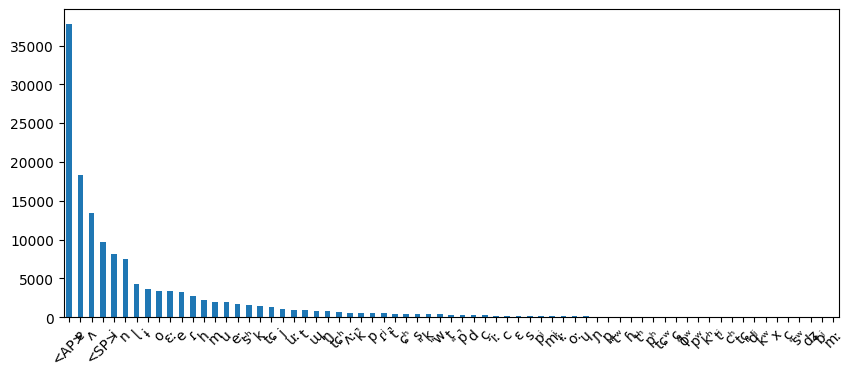

In [5]:
df_anotated_2d = pd.read_csv(feat_2d_path, index_col=0)

n_phones = len(df_anotated_2d['phone_base'].unique())
min_dataset = len(df_anotated_2d['phone_base'])*0.02/60

print(f'Number of phones : {n_phones}')
print(f'Minutes of dataset : {min_dataset}')

plt.figure(figsize=(10,4))
df_anotated_2d['phone_base'].value_counts().plot.bar(rot = 45);

In [6]:
unique_phones = [k for k in df_anotated_2d['phone_base'].value_counts().keys() if k != '<SP>']
print(unique_phones[0:20])

['<AP>', 'ɐ', 'ʌ', 'i', 'n', 'ɭ', 'ɨ', 'o', 'ɛː', 'e', 'ɾ', 'h', 'm', 'u', 'eː', 'sʰ', 'k', 'tɕ', 'j', 'uː']


Making a 2d plot


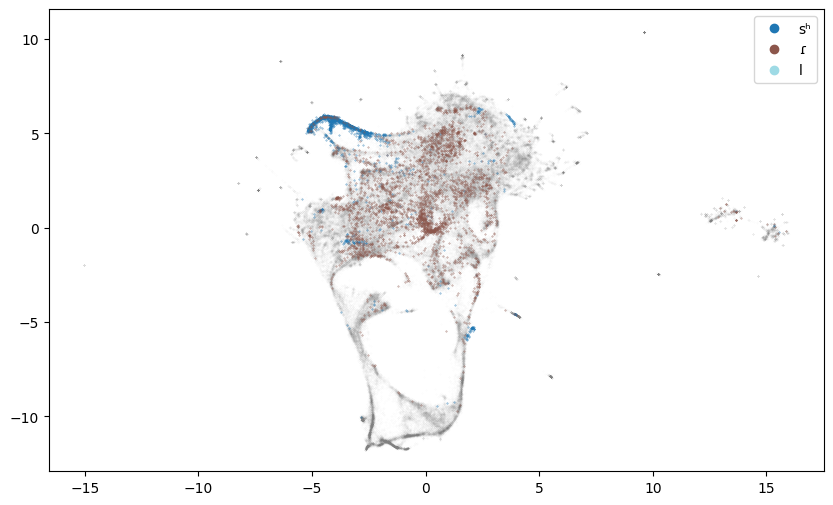

In [8]:
plots.make_tagged_LS_plot(df_anotated_2d,
            phones = ['sʰ',  'ɾ', 'l'],
            alpha = 0.8, 
            s = 0.1,
            show_global=True,
            align_head=True)

# All Languages

In [ ]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/applio/Applio_LS/experiments'

In [76]:
d = {
    'ES': {
        'exp': 'gt_singer_ES_v0',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'u', 's', 'm', 'n']
    },
    'FR': {
        'exp': 'gt_singer_FR_v0',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'u', 's', 'm', 'n']
    },
    'IT': {
        'exp': 'gt_singer_IT_v2',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'u', 's', 'm', 'n']
    },
    'JA': {
        'exp': 'gt_singer_JA_v0',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'u', 's', 'm', 'n']
    },
    'KO': {
        'exp': 'gt_singer_KO_v0',
        'phones': ['<AP>', '<SP>', 'ɐ', 'ʌ', 'i', 'o', 'u',  'sʰ', 'm', 'n']
    }
}

In [77]:
for k in d.keys():
    experiment_path = f'{root}/{d[k]["exp"]}'
    feat_2d_path = f'{experiment_path}/feat_2d/feat_2d_layer_1.csv'

    df_anotated_2d = pd.read_csv(feat_2d_path, index_col=0)
    d[k]['all_phones'] = [k for k in df_anotated_2d['phone_base'].value_counts().keys()]

In [146]:
def make_multilingual_plot(layer):

    os.makedirs('multiling', exist_ok=True)
    fig, axes = plt.subplots(3, 2, figsize = (12,12)) 
    axes = axes.flatten()

    fig.suptitle(f"Layer {layer}", y=1.0)
    for ax, k in zip(axes,d.keys()):
        experiment_path = f'{root}/{d[k]["exp"]}'
        feat_2d_path = f'{experiment_path}/feat_2d/feat_2d_layer_{layer}.csv'

        df_anotated_2d = pd.read_csv(feat_2d_path, index_col=0)
        unique_phones = d[k]['phones']
        ax.set_title(d[k]["exp"])

        plots.make_tagged_LS_plot(df_anotated_2d,
                    phones = unique_phones,
                    alpha = 0.2, 
                    s = 0.3,
                    show_global=True,
                    align_head=True,
                    ax = ax, 
                    add_legend = False,
                    save_csv = f'multiling/layer_{layer}.csv')
    fig.tight_layout()
    #plt.show()
    fig.savefig(f'multiling/layer_{layer}')
    plt.close()

In [ ]:
for l in [8,9,10,11,12]:
    make_multilingual_plot(l)